# 02 CIGNN EMNIST

> EMNIST letter exp

In [2]:
#| default_exp data

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:

import os
import pandas as pd
import sys
sys.path.append(os.path.abspath('..'))

import torch
import torchvision
from torchvision.transforms import ToTensor
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as F
from torchvision.io import read_image, ImageReadMode
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import numpy as np
import scipy


In [3]:
project="CIGNN_GA_VGG16_bn"
n_epochs = 7 
n_generations = 10
n_genomes = 100
n_samples_train = 4096
n_samples_val = 1024
train_split = "/data/datasets/HWR/unipen_curated/split/trn.txt"
val_split = "/data/datasets/HWR/unipen_curated/split/val.txt"
test_split = "/data/datasets/HWR/unipen_curated/split/tst.txt"
data_dir = "/data/datasets/HWR/unipen_curated/curated"
model_save_path = "vgg_unipen_curated.pth"
dev = "cuda"
env = "prod"


In [4]:
# collect all parameters and initialise wandb project
import wandb

wandb.init(
    project=project,
    config = {
        "n_epochs": n_epochs,
        "n_generations": n_generations,
        "n_genomes": n_genomes,
        "n_samples_train": n_samples_train,
        "n_samples_val": n_samples_val, 
        "train_split" : train_split,
        "val_split" : val_split,
        "test_split" : test_split,
        "data_dir" : data_dir,
        "model_save_path" : model_save_path,
        "dev" : dev,
        "env" : env
    }
)



wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: tim-hallyburton (tim-hallyburton-tu-dortmund). Use `wandb login --relogin` to force relogin


In [4]:
    
from dotenv import dotenv_values

env_cfg = {**dotenv_values(f"./env/{env}.env"), **os.environ}


In [5]:
def unipen_char_to_code(char: str) -> int: 
    """Convert a single char into the corresponding 0-based index.

    This method respects the fact that UNIPEN (curated) does not have 
    samples for the "\"-symbol. A simple ofsetting -33 for the ASCII
    chars therefore leads to one "extra class", causing indexing errors
    down the line.

    In particular: 
        chars = [chr(i) for i in range(33, 123) if not i == 92]
        codes = [unipen_char_to_code(c) for c in chars]
        chars2 = [unipen_code_to_char(cc) for cc in codes]
        chars == chars2


    Args:
        char (str): The Char "!" - "z" to index.

    Returns:
        int: 0-based index for the input char, skipping the ascii code 92.
    """

    print(char)
    res = ord(char) - 33 
    return res - 1 if (res > (92 - 33)) else res 

def unipen_code_to_char(code: int) -> str: 
    """Convert a 0-based index int to the corresponding ASCII char in the context of the unipen curated dataset.

    This method avoids indexing errors that can happen because the unipen dataset does not provide samples for ascii char 
    92, so simple +-33 conversions cause one empty extra index.

    In particular: 
        chars = [chr(i) for i in range(33, 123) if not i == 92]
        codes = [unipen_char_to_code(c) for c in chars]
        chars2 = [unipen_code_to_char(cc) for cc in codes]
        chars == chars2

    Args:
        code (int): integer of the index to convert to char.

    Returns:
        str: The char after conversion. 
    """

    code = code if code < (92 - 33) else code + 1
    return chr(33 + code)




In [6]:

# load data from curated dataset 
class UnipenCuratedDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None, n_samples=0):
        self.device = torch.device(dev)
        
        self.img_labels = []
        with open(annotations_file, "r") as fh:
            self._img_labels = [[line.strip(), line.strip().split("/")[0]] for line in fh.readlines()]
            self.img_labels = pd.DataFrame(self._img_labels)

        # If the sampling parameter is given, reduce the existing dataframe to the given amount
        if n_samples > 0:
            self.img_labels = self.img_labels.sample(n=min(n_samples, len(self.img_labels)))

        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path, mode=ImageReadMode.RGB)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image.to(torch.float32).to(self.device), int(label) - 33 if int(label) <= 92 else int(label) - 34


In [7]:
import scipy.ndimage


def generate_dataset(genome=np.ndarray, n_samples_train=0, n_samples_val=0):

    # The transformations can get really crazy, especially if one tries to include the order to apply them into the genome.
    # For this reason, I want to simplify and normalize how the transformation parameters are included for now. I restrict 
    # their parameter range to [0, 1) for now, 0 always meaning that the transformation is not to be applied at all.
    #
    # As for the order of transformations, we start with
    # 
    # 1) Scale Avg
    # 2) Scale Range
    # 3) Rotation Avg
    # 4) Rotation Range
    # 5) Noise Std. Dev.
    # 6) Blur Sigma

    def transform(img):
        original_shape = img.shape  

        # scaling min_max [0.5, 2)
        scale_min = min(genome[0] - genome[1], 0)
        scale_max = max(genome[0] + genome[1], 0)
        scaling_factor = np.random.uniform(low=scale_min, high=scale_max)
        # Apply zoom
        zoomed_img = scipy.ndimage.zoom(img, (scaling_factor, scaling_factor, 1), order=1)

        # Calculate cropping or padding to return to original shape
        zoomed_shape = zoomed_img.shape

        crop_start = [max((zoomed_shape[i] - original_shape[i]) // 2, 0) for i in range(2)]
        crop_end = [crop_start[i] + original_shape[i] for i in range(2)]

        cropped_img = zoomed_img[
            crop_start[0]:crop_end[0],
            crop_start[1]:crop_end[1],
            ...
        ]

        # If cropping was not sufficient, pad the image
        pad_h = original_shape[0] - cropped_img.shape[0]
        pad_w = original_shape[1] - cropped_img.shape[1]

        pad_width = [
            (pad_h // 2, pad_h - pad_h // 2),
            (pad_w // 2, pad_w - pad_w // 2),
            (0, 0)  # No padding for the channel dimension
        ]

        img = np.pad(cropped_img, pad_width, mode='constant', constant_values=0)

        
        # rotation min_max (-180, 180)
        rot_min = genome[2] - genome[3]
        rot_max = genome[2] + genome[3]

        rot_factor = np.random.uniform(low=rot_min, high=rot_max)
        img = scipy.ndimage.rotate(img, rot_factor, axes=(2, 1), reshape=False, order=1)
        
        # additive Gaussian noise
        noise_std_dev = genome[4] 
        noise = np.random.normal(0, noise_std_dev, img.shape)
        img = img + noise
        img = np.clip(img, 0, 1)  # Ensure pixel values remain valid (0-1 range)
        
        # Gaussian blur
        blur_sigma = genome[5] 
        img = scipy.ndimage.gaussian_filter(img, sigma=blur_sigma)
        
        # make sure to return as tensor again

        return torch.tensor(img, dtype=torch.float32)

    train_data = UnipenCuratedDataset(train_split, data_dir, transform=transform, n_samples=n_samples_train)
    train_dataloader = DataLoader(dataset=train_data, batch_size=16, shuffle=True)
    val_data = UnipenCuratedDataset(val_split, data_dir, transform=transform, n_samples=n_samples_val)
    val_dataloader = DataLoader(dataset=val_data, batch_size=16, shuffle=True) 
    
    return train_dataloader, val_dataloader

In [8]:
# Load the EMNIST dataset (one test and one training set, using the "balanced" or "letters" split for example)

test_data = UnipenCuratedDataset(test_split, data_dir)
test_dataloader = DataLoader(dataset=test_data, batch_size=16, shuffle=True)

In [9]:


# the correct #numclass is 93, however, the curated unipen dataset does not have samples for ascii 92 ("\"-symbol")
vgg_bn = torchvision.models.vgg16_bn(num_classes=93)
   
device = torch.device(dev)
vgg_bn.to(device)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

In [29]:
model = vgg_bn
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training loop with validation and checkpoint saving

#genome = np.random.rand(6) * np.array([0, 1, 0, 0, 0, 0])
genome = np.array([1, 0.5, 20, 10, 0.05, 0])
print(genome)
    
train_dataloader, val_dataloader = generate_dataset(genome=genome, n_samples_train=2048, n_samples_val=1024)
print(len(train_dataloader))
print(len(val_dataloader))

[ 1.    0.5  20.   10.    0.05  0.  ]
128
64


In [26]:
b, l = next(iter(test_dataloader))

img = b[0].cpu()
print(img.shape)
img2 = scipy.ndimage.rotate(img, 90, axes=(2, 1), reshape=False, order=1)
print(img2.shape)
img2[:,30:60,30:60]


torch.Size([3, 64, 64])
(3, 64, 64)


array([[[255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 205.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 205.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 205.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]]], dtype=float32)

tensor([[ 0.0074, -0.0265, -0.0187,  ...,  0.0205, -0.0255,  0.0338],
        [ 0.0019, -0.0332, -0.0195,  ...,  0.0218, -0.0169,  0.0368],
        [ 0.0013, -0.0290, -0.0158,  ...,  0.0272, -0.0185,  0.0349],
        ...,
        [-0.0002, -0.0121, -0.0071,  ...,  0.0101, -0.0097,  0.0133],
        [ 0.0006, -0.0026, -0.0014,  ...,  0.0018, -0.0014,  0.0027],
        [ 0.0036, -0.0259, -0.0096,  ...,  0.0169, -0.0175,  0.0286]],
       device='cuda:0')
torch.Size([16, 93])
tensor([[[0.0000, 0.0220, 0.0237,  ..., 0.0296, 0.0000, 0.0347],
         [0.0000, 0.0000, 0.0072,  ..., 0.0326, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0827,  ..., 0.0000, 0.0019, 0.0097],
         ...,
         [0.0000, 0.0766, 0.0000,  ..., 0.0625, 0.0214, 0.0000],
         [0.0000, 0.0676, 0.1217,  ..., 0.0000, 0.0000, 0.0279],
         [0.0000, 0.0000, 0.0554,  ..., 0.0208, 0.0372, 0.0220]],

        [[0.0095, 0.0000, 0.0413,  ..., 0.0000, 0.0459, 0.0000],
         [0.0000, 0.0000, 0.0058,  ..., 0.0000, 0.

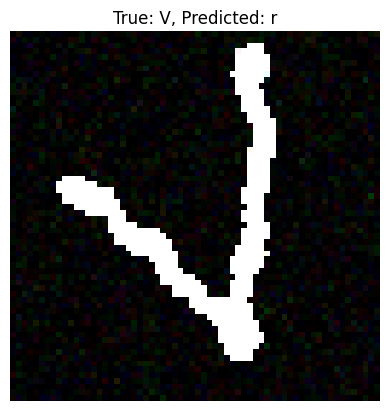

tensor([[[1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0000, 0.0000],
         [1.0000, 1.0000, 1.0000,  ..., 0.0936, 0.0000, 0.0000],
         [1.0000, 1.0000, 1.0000,  ..., 0.1035, 0.0000, 0.0067],
         ...,
         [0.0263, 0.0363, 0.0161,  ..., 0.0970, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0500,  ..., 0.0000, 0.0000, 0.0029],
         [0.0373, 0.0269, 0.0000,  ..., 0.0789, 0.0171, 0.0052]],

        [[1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0563, 0.0610],
         [1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0000, 0.0014],
         [1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0308, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0035,  ..., 0.0969, 0.0355, 0.0000],
         [0.0171, 0.0292, 0.0049,  ..., 0.0000, 0.0128, 0.0411],
         [0.0000, 0.0000, 0.0180,  ..., 0.0000, 0.0273, 0.0130]],

        [[1.0000, 1.0000, 1.0000,  ..., 0.0065, 0.0227, 0.0000],
         [1.0000, 1.0000, 1.0000,  ..., 0.0319, 0.0801, 0.0000],
         [1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0025, 0.

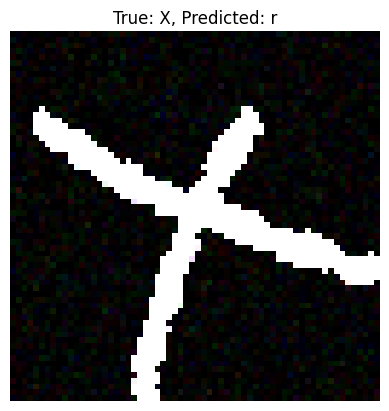

tensor([[[0.0610, 0.0000, 0.0171,  ..., 0.0304, 0.0000, 0.0000],
         [0.0480, 0.0000, 0.0387,  ..., 0.0131, 0.0000, 0.0399],
         [0.0735, 0.0000, 0.0000,  ..., 1.0000, 0.0000, 0.0718],
         ...,
         [0.0525, 0.0000, 0.0070,  ..., 0.0000, 0.0000, 0.0624],
         [0.0345, 0.0000, 0.0783,  ..., 0.0067, 0.0340, 0.0349],
         [0.0000, 0.0000, 0.0000,  ..., 0.0792, 0.0000, 0.0558]],

        [[0.0666, 0.0000, 0.0000,  ..., 0.0000, 0.0030, 0.0079],
         [0.0000, 0.0000, 0.0260,  ..., 0.0549, 0.0042, 0.0300],
         [0.0204, 0.0445, 0.0000,  ..., 1.0000, 0.0000, 0.0573],
         ...,
         [0.0000, 0.0306, 0.0213,  ..., 0.0218, 0.0000, 0.0522],
         [0.0158, 0.0000, 0.0451,  ..., 0.0842, 0.0307, 0.0000],
         [0.0186, 0.0000, 0.0034,  ..., 0.0473, 0.0000, 0.0000]],

        [[0.0418, 0.0000, 0.0000,  ..., 0.0000, 0.0573, 0.0293],
         [0.0047, 0.0325, 0.0641,  ..., 0.0000, 0.0127, 0.0000],
         [0.0456, 0.0000, 0.0837,  ..., 1.0000, 0.0355, 0.

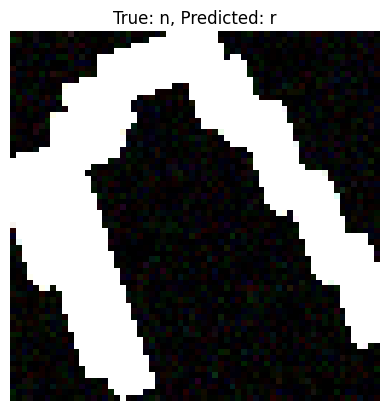

tensor([[[0.0000, 0.0000, 0.0459,  ..., 0.0834, 0.0270, 0.0000],
         [0.0071, 0.0253, 0.0000,  ..., 0.0576, 0.0436, 0.0000],
         [0.0216, 0.0270, 0.0521,  ..., 0.0360, 0.0000, 0.0000],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0370, 0.0000],
         [1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0000, 0.0219],
         [1.0000, 1.0000, 1.0000,  ..., 0.0979, 0.0000, 0.0000]],

        [[0.0256, 0.0000, 0.0122,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0487, 0.0000,  ..., 0.0223, 0.0823, 0.0473],
         [0.1373, 0.0633, 0.0661,  ..., 0.0000, 0.0000, 0.0350],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 0.0342, 0.0000, 0.0000],
         [1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0000, 0.0127],
         [1.0000, 1.0000, 1.0000,  ..., 0.0695, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0487,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0349,  ..., 0.0761, 0.0000, 0.0000],
         [0.0083, 0.0677, 0.0000,  ..., 0.0000, 0.0000, 0.

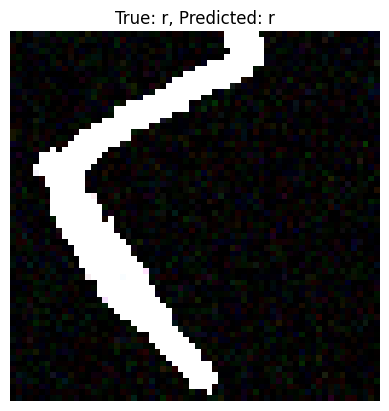

tensor([[[0.0000, 0.0000, 0.0735,  ..., 0.0382, 0.0310, 0.0970],
         [0.0469, 0.0000, 0.0981,  ..., 0.0091, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0105, 0.0000, 0.0174],
         ...,
         [0.0000, 0.0000, 0.0784,  ..., 0.0000, 0.0018, 0.0000],
         [0.0000, 0.0000, 0.0012,  ..., 0.0585, 0.0211, 0.0029],
         [0.0000, 0.0263, 0.0412,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0197, 0.0000, 0.0880,  ..., 0.0772, 0.0566, 0.0928],
         [0.0231, 0.0488, 0.0399,  ..., 0.0000, 0.0000, 0.0289],
         [0.0000, 0.0756, 0.0384,  ..., 0.0000, 0.0355, 0.0288],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0100],
         [0.0276, 0.0000, 0.0218,  ..., 0.0000, 0.0388, 0.0090],
         [0.0705, 0.0544, 0.0142,  ..., 0.0000, 0.1030, 0.0000]],

        [[0.0639, 0.0372, 0.0038,  ..., 0.0000, 0.0000, 0.0000],
         [0.0286, 0.0771, 0.0000,  ..., 0.0000, 0.0093, 0.0252],
         [0.0134, 0.0000, 0.0508,  ..., 0.0464, 0.0000, 0.

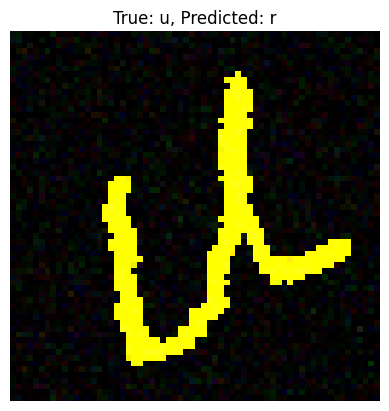

tensor([[[1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 0.0000e+00,
          3.0888e-02, 2.0704e-02],
         [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 2.4011e-02,
          4.6635e-03, 0.0000e+00],
         [1.0000e+00, 1.0000e+00, 4.8347e-02,  ..., 0.0000e+00,
          2.1552e-02, 9.2969e-02],
         ...,
         [9.2010e-02, 4.4077e-02, 1.2967e-02,  ..., 0.0000e+00,
          0.0000e+00, 2.7767e-02],
         [0.0000e+00, 0.0000e+00, 8.9510e-02,  ..., 6.7190e-02,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 1.0006e-02,  ..., 0.0000e+00,
          2.5391e-02, 2.2084e-02]],

        [[1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 9.2348e-02,
          6.9086e-02, 0.0000e+00],
         [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [1.0000e+00, 1.0000e+00, 2.8198e-02,  ..., 0.0000e+00,
          3.3389e-02, 0.0000e+00],
         ...,
         [3.0774e-02, 0.0000e+00, 9.3261e-02,  ..., 4.1436e-02,
          3.856

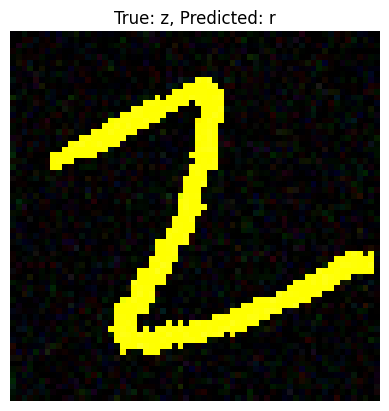

tensor([[[1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 9.0941e-02],
         [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 0.0000e+00,
          4.8785e-02, 3.9273e-02],
         ...,
         [0.0000e+00, 0.0000e+00, 1.0000e+00,  ..., 0.0000e+00,
          1.3745e-02, 1.7319e-02],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 1.0331e-01]],

        [[1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 0.0000e+00,
          2.1860e-02, 0.0000e+00],
         [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 6.7221e-02,
          2.3094e-03, 1.0253e-02],
         [1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 3.0492e-02],
         ...,
         [6.9942e-02, 0.0000e+00, 1.0000e+00,  ..., 5.0684e-02,
          0.000

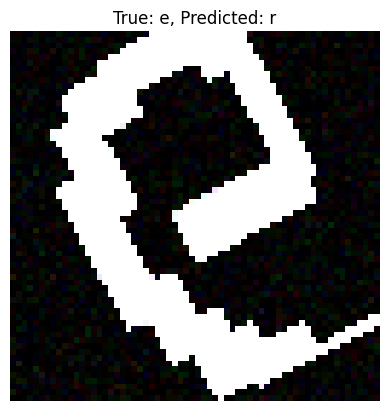

tensor([[[1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0000, 0.0203],
         [1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0271, 0.0825],
         [0.0437, 1.0000, 1.0000,  ..., 0.0066, 0.0000, 0.0059],
         ...,
         [0.1043, 0.0971, 0.0061,  ..., 0.0163, 0.0000, 0.0825],
         [0.0000, 0.0168, 0.0171,  ..., 0.0344, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0195,  ..., 0.0000, 0.0225, 0.0000]],

        [[1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0000, 0.0719],
         [1.0000, 1.0000, 1.0000,  ..., 0.0000, 0.0000, 0.0327],
         [0.0139, 1.0000, 1.0000,  ..., 0.0000, 0.0300, 0.0132],
         ...,
         [0.0000, 0.0769, 0.0724,  ..., 0.0000, 0.0000, 0.0138],
         [0.0260, 0.0000, 0.0547,  ..., 0.0000, 0.0000, 0.0842],
         [0.0101, 0.0317, 0.0074,  ..., 0.0237, 0.0000, 0.0000]],

        [[0.0000, 0.0403, 0.0000,  ..., 0.0469, 0.0722, 0.0587],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0058, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0118, 0.0000, 0.

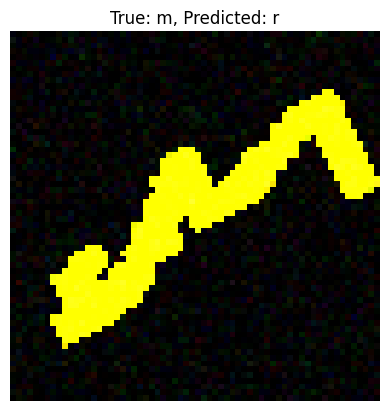

tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 6.5338e-02,
          0.0000e+00, 0.0000e+00],
         [1.6678e-03, 0.0000e+00, 0.0000e+00,  ..., 7.1883e-03,
          1.9512e-02, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.3965e-02,
          0.0000e+00, 2.0234e-02],
         ...,
         [1.3413e-02, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          2.0145e-02, 0.0000e+00],
         [0.0000e+00, 3.4538e-02, 8.5493e-02,  ..., 3.3604e-02,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 4.7200e-02, 0.0000e+00,  ..., 1.9574e-02,
          1.0758e-02, 9.8067e-03]],

        [[0.0000e+00, 2.9920e-02, 0.0000e+00,  ..., 6.9810e-05,
          2.6873e-02, 1.1442e-01],
         [0.0000e+00, 5.8251e-03, 0.0000e+00,  ..., 4.1805e-02,
          0.0000e+00, 0.0000e+00],
         [2.8792e-02, 1.8757e-02, 8.0501e-02,  ..., 9.0147e-02,
          0.0000e+00, 0.0000e+00],
         ...,
         [1.7419e-02, 5.8938e-02, 0.0000e+00,  ..., 4.7557e-02,
          7.892

In [30]:
import matplotlib.pyplot as plt
import torch

# Function to display an image and its labels
def show_sample(image, true_label, predicted_label):

    # The .permute call is required to transpose the image. We receive a shape (3, 64, 64) here
    # but .imshow() expects a shape with the channels at the end, like (64, 64, 3)
    image = image.permute(1, 2, 0)
    image = image.cpu().squeeze().numpy()  # Convert to 2D array for display
    plt.imshow(image)
    print(true_label)
    print(predicted_label)
    plt.title(f"True: {unipen_code_to_char(true_label)}, Predicted: {unipen_code_to_char(predicted_label)}")  
    plt.axis('off')
    plt.show()

# Run inference and display samples
model.eval()
num_samples_to_show = 8
shown_samples = 0

with torch.no_grad():
    for images, labels in train_dataloader:
        outputs = model(images)
        print(outputs)
        print(outputs.shape)
        probs, predicted = torch.max(outputs, 1)

        for i in range(len(images)):
            print(images[i][:,30:60,30:60])

            if shown_samples >= num_samples_to_show:
                break
            true_label = labels[i].item()
            predicted_label = predicted[i].item()
            # Shift by -1 to match a=1, ..., z=26 in EMNIST "letters"
            show_sample(images[i], true_label, predicted_label )
            shown_samples += 1
        
        if shown_samples >= num_samples_to_show:
            break

In [ ]:

best_val_loss = float('inf')  # Initialize the best validation loss
checkpoint_path = 'best_model_checkpoint.pth'  # Path to save the best model

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    # Training phase
    for batch_idx, (images, labels) in enumerate(train_dataloader, start=1):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()  # Clear gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights
        running_loss += loss.item()

        # Print progress every 10 batches
        if batch_idx % 10 == 0:
            wandb.log({"train_loss": loss.item()})
            print(f"Epoch [{epoch+1}/{n_epochs}], Batch [{batch_idx}/{len(train_dataloader)}], Loss: {running_loss/batch_idx:.4f}")

    avg_train_loss = running_loss / len(train_dataloader)
    print(f"Epoch [{epoch+1}/{n_epochs}], Training Loss: {avg_train_loss:.4f}")

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_dataloader:  # Use a separate validation dataloader
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Calculate validation loss
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_dataloader)
    print(f"Epoch [{epoch+1}/{n_epochs}], Validation Loss: {avg_val_loss:.4f}")
    wandb.log({"val_loss": loss.item()})


    # Checkpoint saving
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Best model updated and saved at epoch {epoch+1} with Validation Loss: {avg_val_loss:.4f}")

# Testing loop
model.load_state_dict(torch.load(checkpoint_path))  # Load the best model checkpoint
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)  # Forward pass
        predicted = outputs.argmax(dim=1)  # Get predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")
wandb.log({"test_acc": accuracy})


In [16]:
from torch import nn

# Get the activation at the penultimate layer

# Interestingly, this is the final non-flat layer 512x7x7
# when I would have expected it to be the final dense layer
# right before the Softmax (4094 -> #numclass)
embedding_model = nn.Sequential(*list(model.children())[:-1])

# try clustering features and penultimate activation
for name, i in model.named_children():
    if name == 'classifier':
        print(i)  # this is how we can get that layer


# Run inference and display samples
embedding_model.eval()
num_samples_to_show = 5
shown_samples = 0

with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = embedding_model(images)
        
        print(outputs.shape)
        break
        

torch.Size([16, 512, 7, 7])


In [33]:
# Reference datasetes (without transformations etc)
from sklearn.cluster import KMeans
from collections import Counter


ref_train_data = UnipenCuratedDataset(train_split, data_dir)
ref_train_dataloader = DataLoader(dataset=ref_train_data, batch_size=32, shuffle=True)
ref_val_data = UnipenCuratedDataset(val_split, data_dir)
ref_val_dataloader = DataLoader(dataset=ref_val_data, batch_size=32, shuffle=True) 

# Initialize random genomes
genomes = [np.random.rand(4) for _ in range(n_genomes)]

# For each generation of the algorithm ...
for generation in range(n_generations):

    # For each genome, generate a training and validation dataset
    for genome in genomes:

        train_dataloader, val_dataloader = generate_dataset(genome=genome, n_samples_train=n_samples_train, n_samples_val=n_samples_val)
        

        # train the reference network with this data
        # Make sure the model is a **new instance**
        vgg_bn = torchvision.models.vgg16_bn(num_classes=93)
        vgg_bn.to(device)
        model = vgg_bn

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.0001)

        # Train the reference network 
        for epoch in range(n_epochs):
            model.train()
            running_loss = 0.0

            # Training phase
            for batch_idx, (images, labels) in enumerate(train_dataloader, start=1):
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()  # Clear gradients
                outputs = model(images)  # Forward pass
                loss = criterion(outputs, labels)  # Calculate loss
                loss.backward()  # Backward pass
                optimizer.step()  # Update weights
                running_loss += loss.item()

                # Print progress every 10 batches
                if batch_idx % 10 == 0:
                    wandb.log({"train_loss": loss.item()})


            # Validation phase
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for images, labels in val_dataloader:  # Use a separate validation dataloader
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)  # Forward pass
                    loss = criterion(outputs, labels)  # Calculate validation loss
                    val_loss += loss.item()

            avg_val_loss = val_loss / len(val_dataloader)
            wandb.log({"average val loss": avg_val_loss})


        # Evaluate the clustering metrics of the network
        # To generate the clusters we run a single pass on train+val set using true labels 
        # and the activation at the FCN output layer. It is important to use datasets here wihtout the
        # augmentations and transformations. 
        # The algorithm used a single-pass kNN with n_classes = n_clusters.
        # To evaluate the resulting clusters we use the reference (testing) set. 


        model.eval()

        all_features, all_labels = [], []

        with torch.no_grad():
            for images, labels in [ref_train_dataloader, ref_val_dataloader]:
                images, labels = images.to(device), labels.to(device)
                features = model.features(images)  # Extract convolutional features
                features_flat = features.view(features.size(0), -1)  # Flatten the features for the classifier
                outputs = vgg_bn.classifier[:5](features_flat)  # this is the layer with size 4096 

                all_features.append(outputs.cpu().numpy())
                all_labels.append(labels.cpu().numpy())
                
        all_features = np.concatenate(all_features, axis=0)
        all_labels = np.concatenate(all_labels, axis=0)


        num_clusters = len(np.unique(all_labels))  # Number of clusters = Number of classes
        kmeans = KMeans(n_clusters=num_clusters, random_state=42)
        kmeans.fit(all_features)  # Fit on the combined features

        # Map clusters to classes based on majority vote
        cluster_to_class = {}
        for cluster_id in range(num_clusters):
            # Get indices of points in the current cluster
            cluster_indices = np.where(kmeans.labels_ == cluster_id)[0]
            # Find the most common class label in this cluster
            majority_class = Counter(all_labels[cluster_indices]).most_common(1)[0][0]
            cluster_to_class[cluster_id] = majority_class



        # Evaluate on a reference (test) set
        ref_features = []
        ref_labels = []

        with torch.no_grad():
            for images, labels in ref_test_dataloader:  # Replace with your test dataloader
                images, labels = images.to(device), labels.to(device)
                
                # Extract features
                features = model.features(images)
                features_flat = features.view(features.size(0), -1)
                outputs = vgg_bn.classifier[:5](features_flat)
                
                # Append features and labels
                ref_features.append(outputs.cpu().numpy())
                ref_labels.append(labels.cpu().numpy())

        # Combine reference features and labels
        ref_features = np.concatenate(ref_features, axis=0)
        ref_labels = np.concatenate(ref_labels, axis=0)

        # Predict clusters for reference data
        ref_clusters = kmeans.predict(ref_features)

        # Map clusters to predicted classes
        ref_predicted_labels = [cluster_to_class[cluster_id] for cluster_id in ref_clusters]

        # Evaluate clustering performance
        from sklearn.metrics import accuracy_score
        accuracy = accuracy_score(ref_labels, ref_predicted_labels)


        
        # log a few training samples, along with the genome sequence
        sample_batch_images, sample_batch_labels = next(iter(train_dataloader))
        sample_images = wandb.Image(sample_batch_images, caption=f"Generation: {generation}, Labels: {sample_batch_labels}, Genome: {genome}")
        wandb.log({"Data Sample": sample_images})

        # cleanup the model and datasets to save resources
        del vgg_bn       
        del train_dataloader
        del val_dataloader
        torch.cuda.empty_cache()
    
     





IndexError: index 4 is out of bounds for axis 0 with size 4

In [32]:
vgg_bn = torchvision.models.vgg16_bn(num_classes=93)
for name, i in vgg_bn.named_children():
    if name == 'classifier':
        print(i)

# Input to test
x = torch.randn(1, 3, 224, 224)  # Example input tensor (batch size 1, 3 channels, 224x224)

# Forward pass to the activation after the 4th layer of the classifier
features = vgg_bn.features(x)  # Extract convolutional features
features_flat = features.view(features.size(0), -1)  # Flatten the features for the classifier
output = vgg_bn.classifier[:5](features_flat)  # Pass through layers up to and including the 4th in the classifier

output.shape

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=93, bias=True)
)


torch.Size([1, 4096])

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()